# From Raw to z-scored+divided+clipped

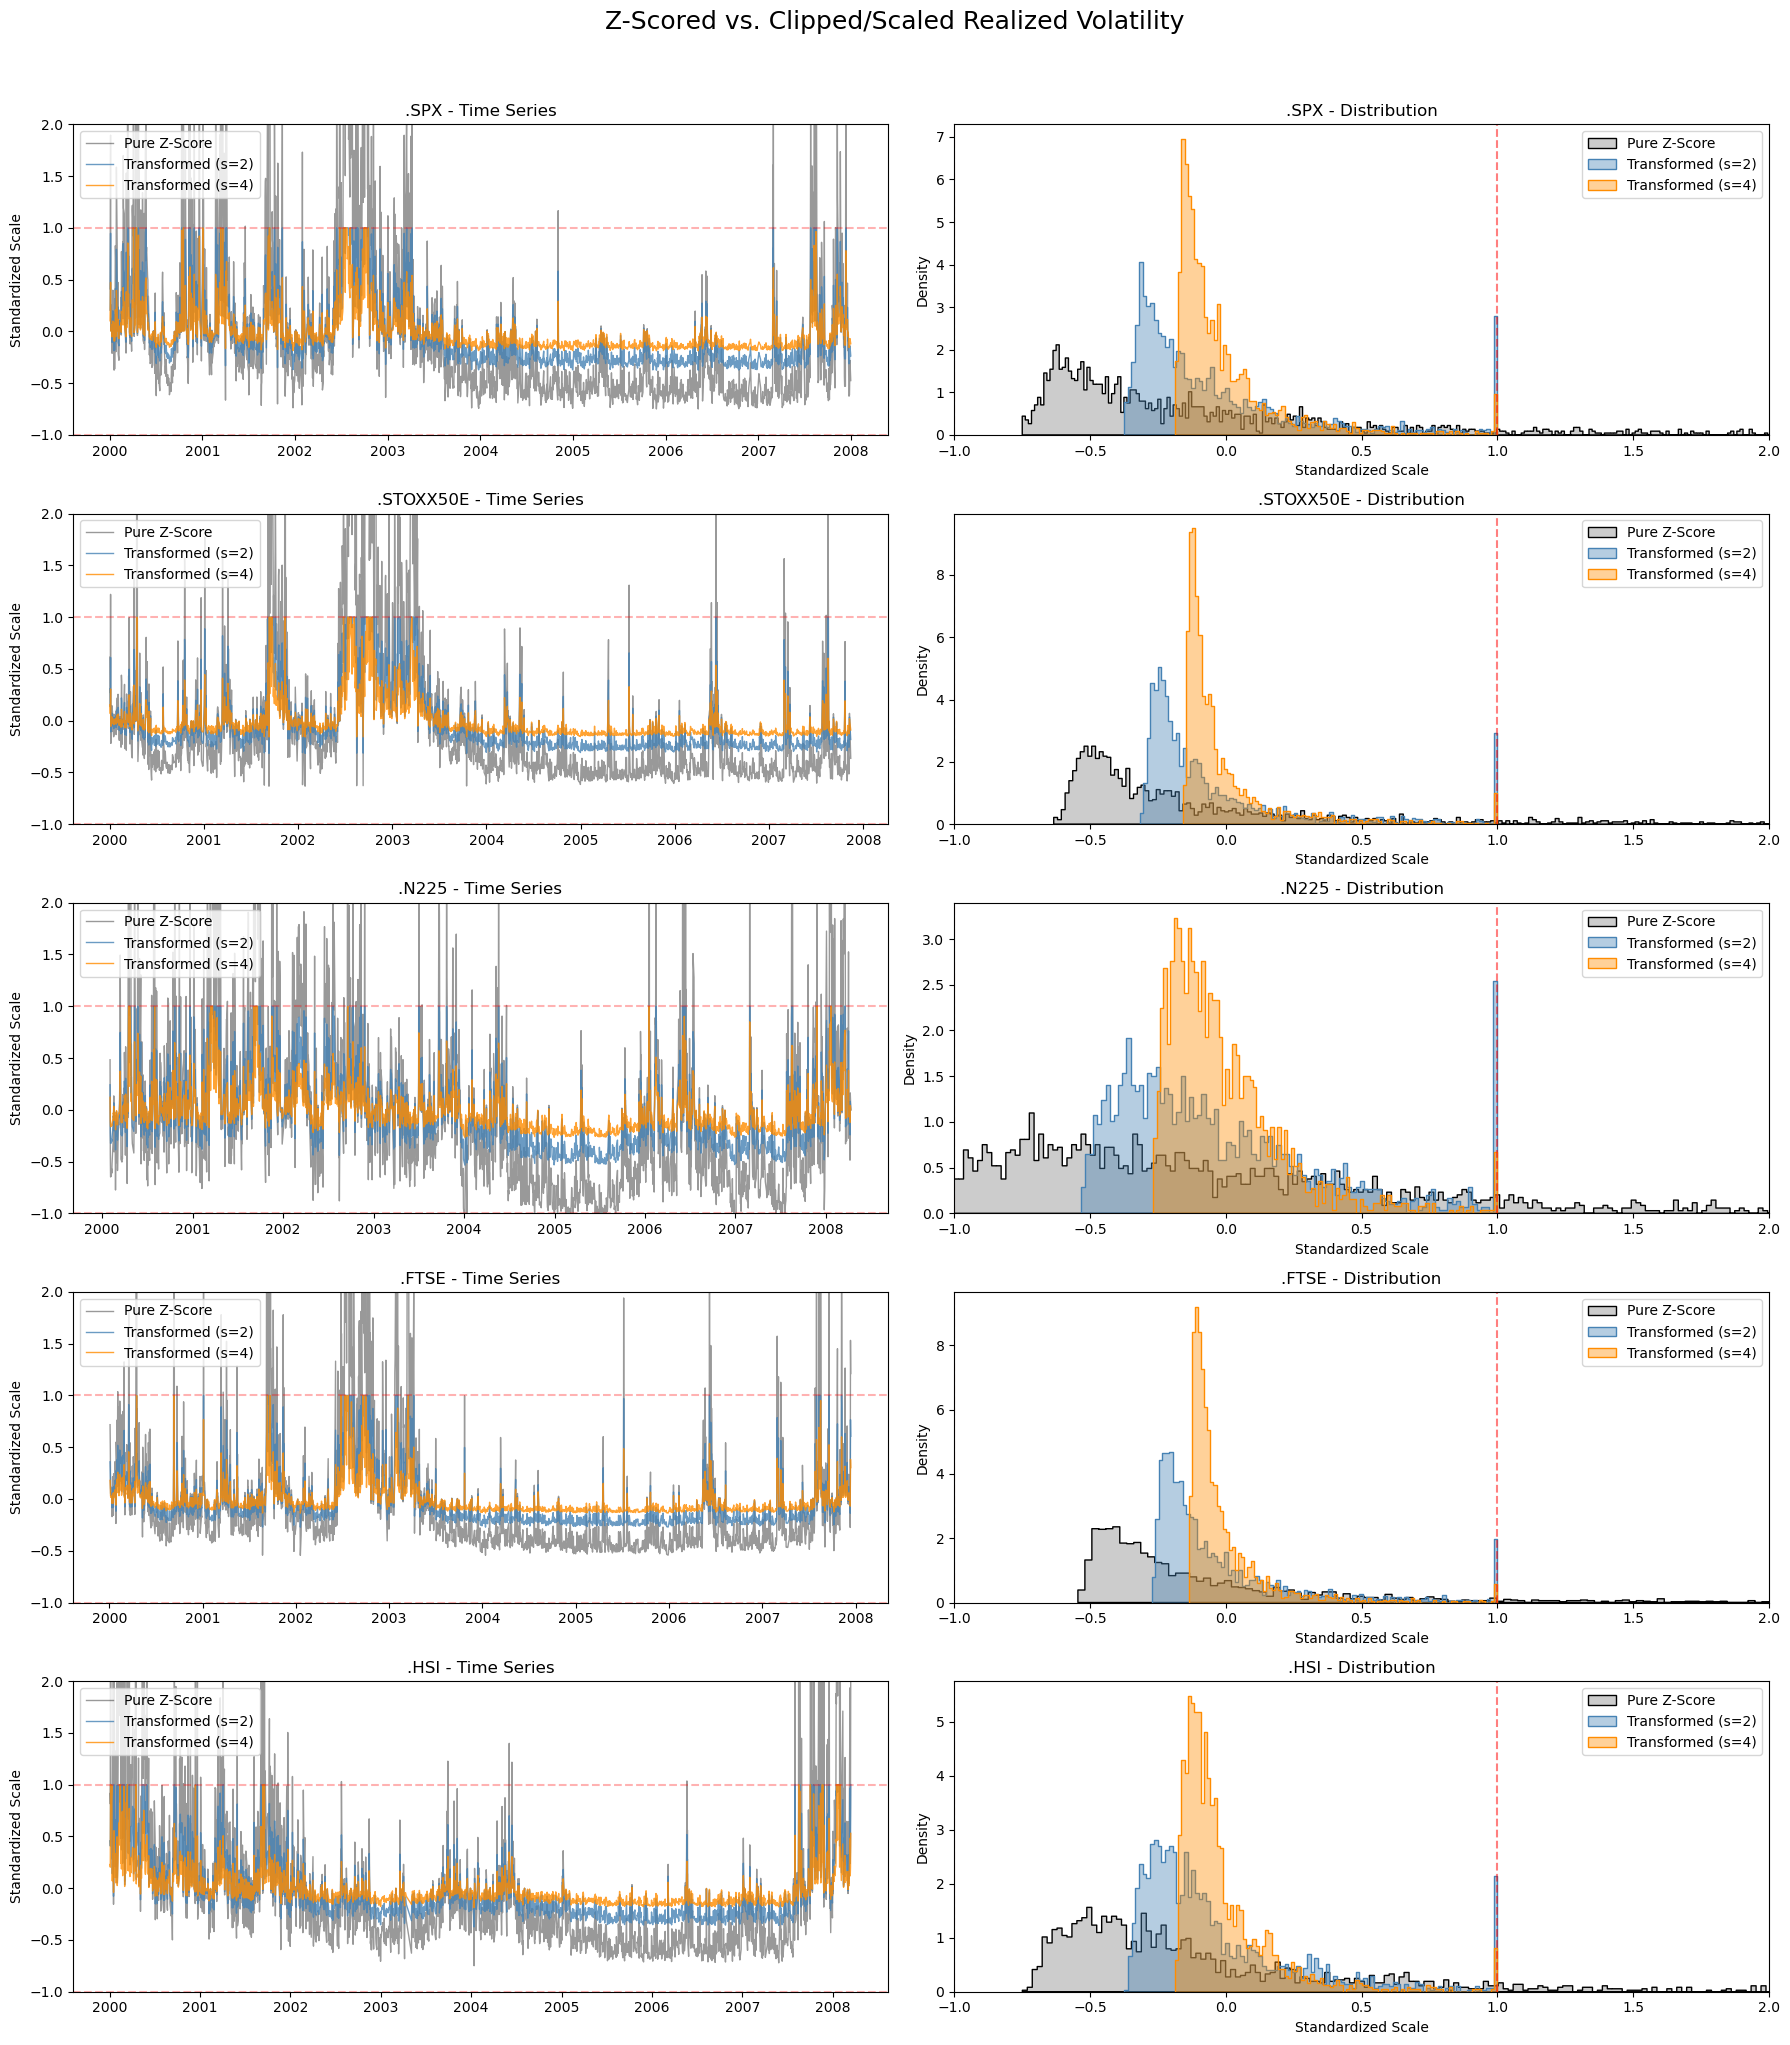

In [16]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Adjust these imports based on your exact project structure
from data.data_loader import load_rv
from utils.transform import TimeSeriesTransformer

start = 0
end = 2000

# 1. Setup Configuration
csv_path = 'rv.csv'
target_col = 'rv5'
selected_tickers = ['.SPX', '.STOXX50E', '.N225', '.FTSE', '.HSI']

# Initialize our transformers
# Default is scalar=1.0 and no clipping, which gives us the pure Z-score
transform_z = TimeSeriesTransformer(scalar=1.0, clip_min=None, clip_max=None)
transform_s2 = TimeSeriesTransformer(scalar=2.0, clip_min=-1.0, clip_max=1.0)
transform_s4 = TimeSeriesTransformer(scalar=4.0, clip_min=-1.0, clip_max=1.0)

# Set up a 5x2 grid for plotting (Rows = Tickers, Col 1 = Time Series, Col 2 = Histograms)
fig, axes = plt.subplots(nrows=len(selected_tickers), ncols=2, figsize=(18, 4 * len(selected_tickers)))
fig.suptitle("Z-Scored vs. Clipped/Scaled Realized Volatility", fontsize=18, y=1.02)

for i, ticker in enumerate(selected_tickers):
    # Load raw data
    raw_values, dates = load_rv(csv_path, symbol=ticker, target=target_col, log_transform=False)
    if end is not None:
        raw_values, dates = raw_values[start:end], dates[start:end]
    else:
        raw_values, dates = raw_values[start:], dates[start:]

    # Fit and transform the data
    transform_z.fit(raw_values)
    z_scores = transform_z.transform(raw_values)
    
    transform_s2.fit(raw_values)
    y_s2 = transform_s2.transform(raw_values)
    
    transform_s4.fit(raw_values)
    y_s4 = transform_s4.transform(raw_values)
    
    # ==========================================
    # PLOT 1: Time Series (Left Column)
    # ==========================================
    ax_ts = axes[i, 0]
    
    # Plot everything on the same axis
    ax_ts.plot(dates, z_scores, color='black', alpha=0.4, linewidth=1, label='Pure Z-Score')
    ax_ts.plot(dates, y_s2, color='steelblue', alpha=0.8, linewidth=1, label='Transformed (s=2)')
    ax_ts.plot(dates, y_s4, color='darkorange', alpha=0.8, linewidth=1, label='Transformed (s=4)')
    
    # Formatting
    ax_ts.set_title(f"{ticker} - Time Series")
    ax_ts.set_ylabel("Standardized Scale")
    ax_ts.set_ylim((-1,2))
    
    # Add horizontal lines to highlight the clip bounds
    ax_ts.axhline(1, color='red', linestyle='--', alpha=0.3)
    ax_ts.axhline(-1, color='red', linestyle='--', alpha=0.3)
    ax_ts.legend(loc='upper left')
    
    # ==========================================
    # PLOT 2: Histograms (Right Column)
    # ==========================================
    ax_hist = axes[i, 1]
    
    # Plot densities on a single shared X-axis
    sns.histplot(z_scores, bins=1000, color='black', alpha=0.2, stat='density', 
                 label='Pure Z-Score', ax=ax_hist, element="step")
    sns.histplot(y_s2, bins=100, color='steelblue', alpha=0.4, stat='density', 
                 label='Transformed (s=2)', ax=ax_hist, element="step")
    sns.histplot(y_s4, bins=100, color='darkorange', alpha=0.4, stat='density', 
                 label='Transformed (s=4)', ax=ax_hist, element="step")
    
    # Formatting
    ax_hist.set_title(f"{ticker} - Distribution")
    ax_hist.set_xlabel("Standardized Scale")
    
    # Restrict X-axis slightly so the extreme z-score tails don't compress the view too much,
    # but keep it wide enough to see the difference between the clip and the raw tails.
    ax_hist.set_xlim(-1, 2) 
    
    # Add vertical lines at clip boundaries
    ax_hist.axvline(x=-1, color='red', linestyle='--', alpha=0.5)
    ax_hist.axvline(x=1, color='red', linestyle='--', alpha=0.5)

    ax_hist.legend(loc='upper right')

plt.tight_layout()
plt.show()

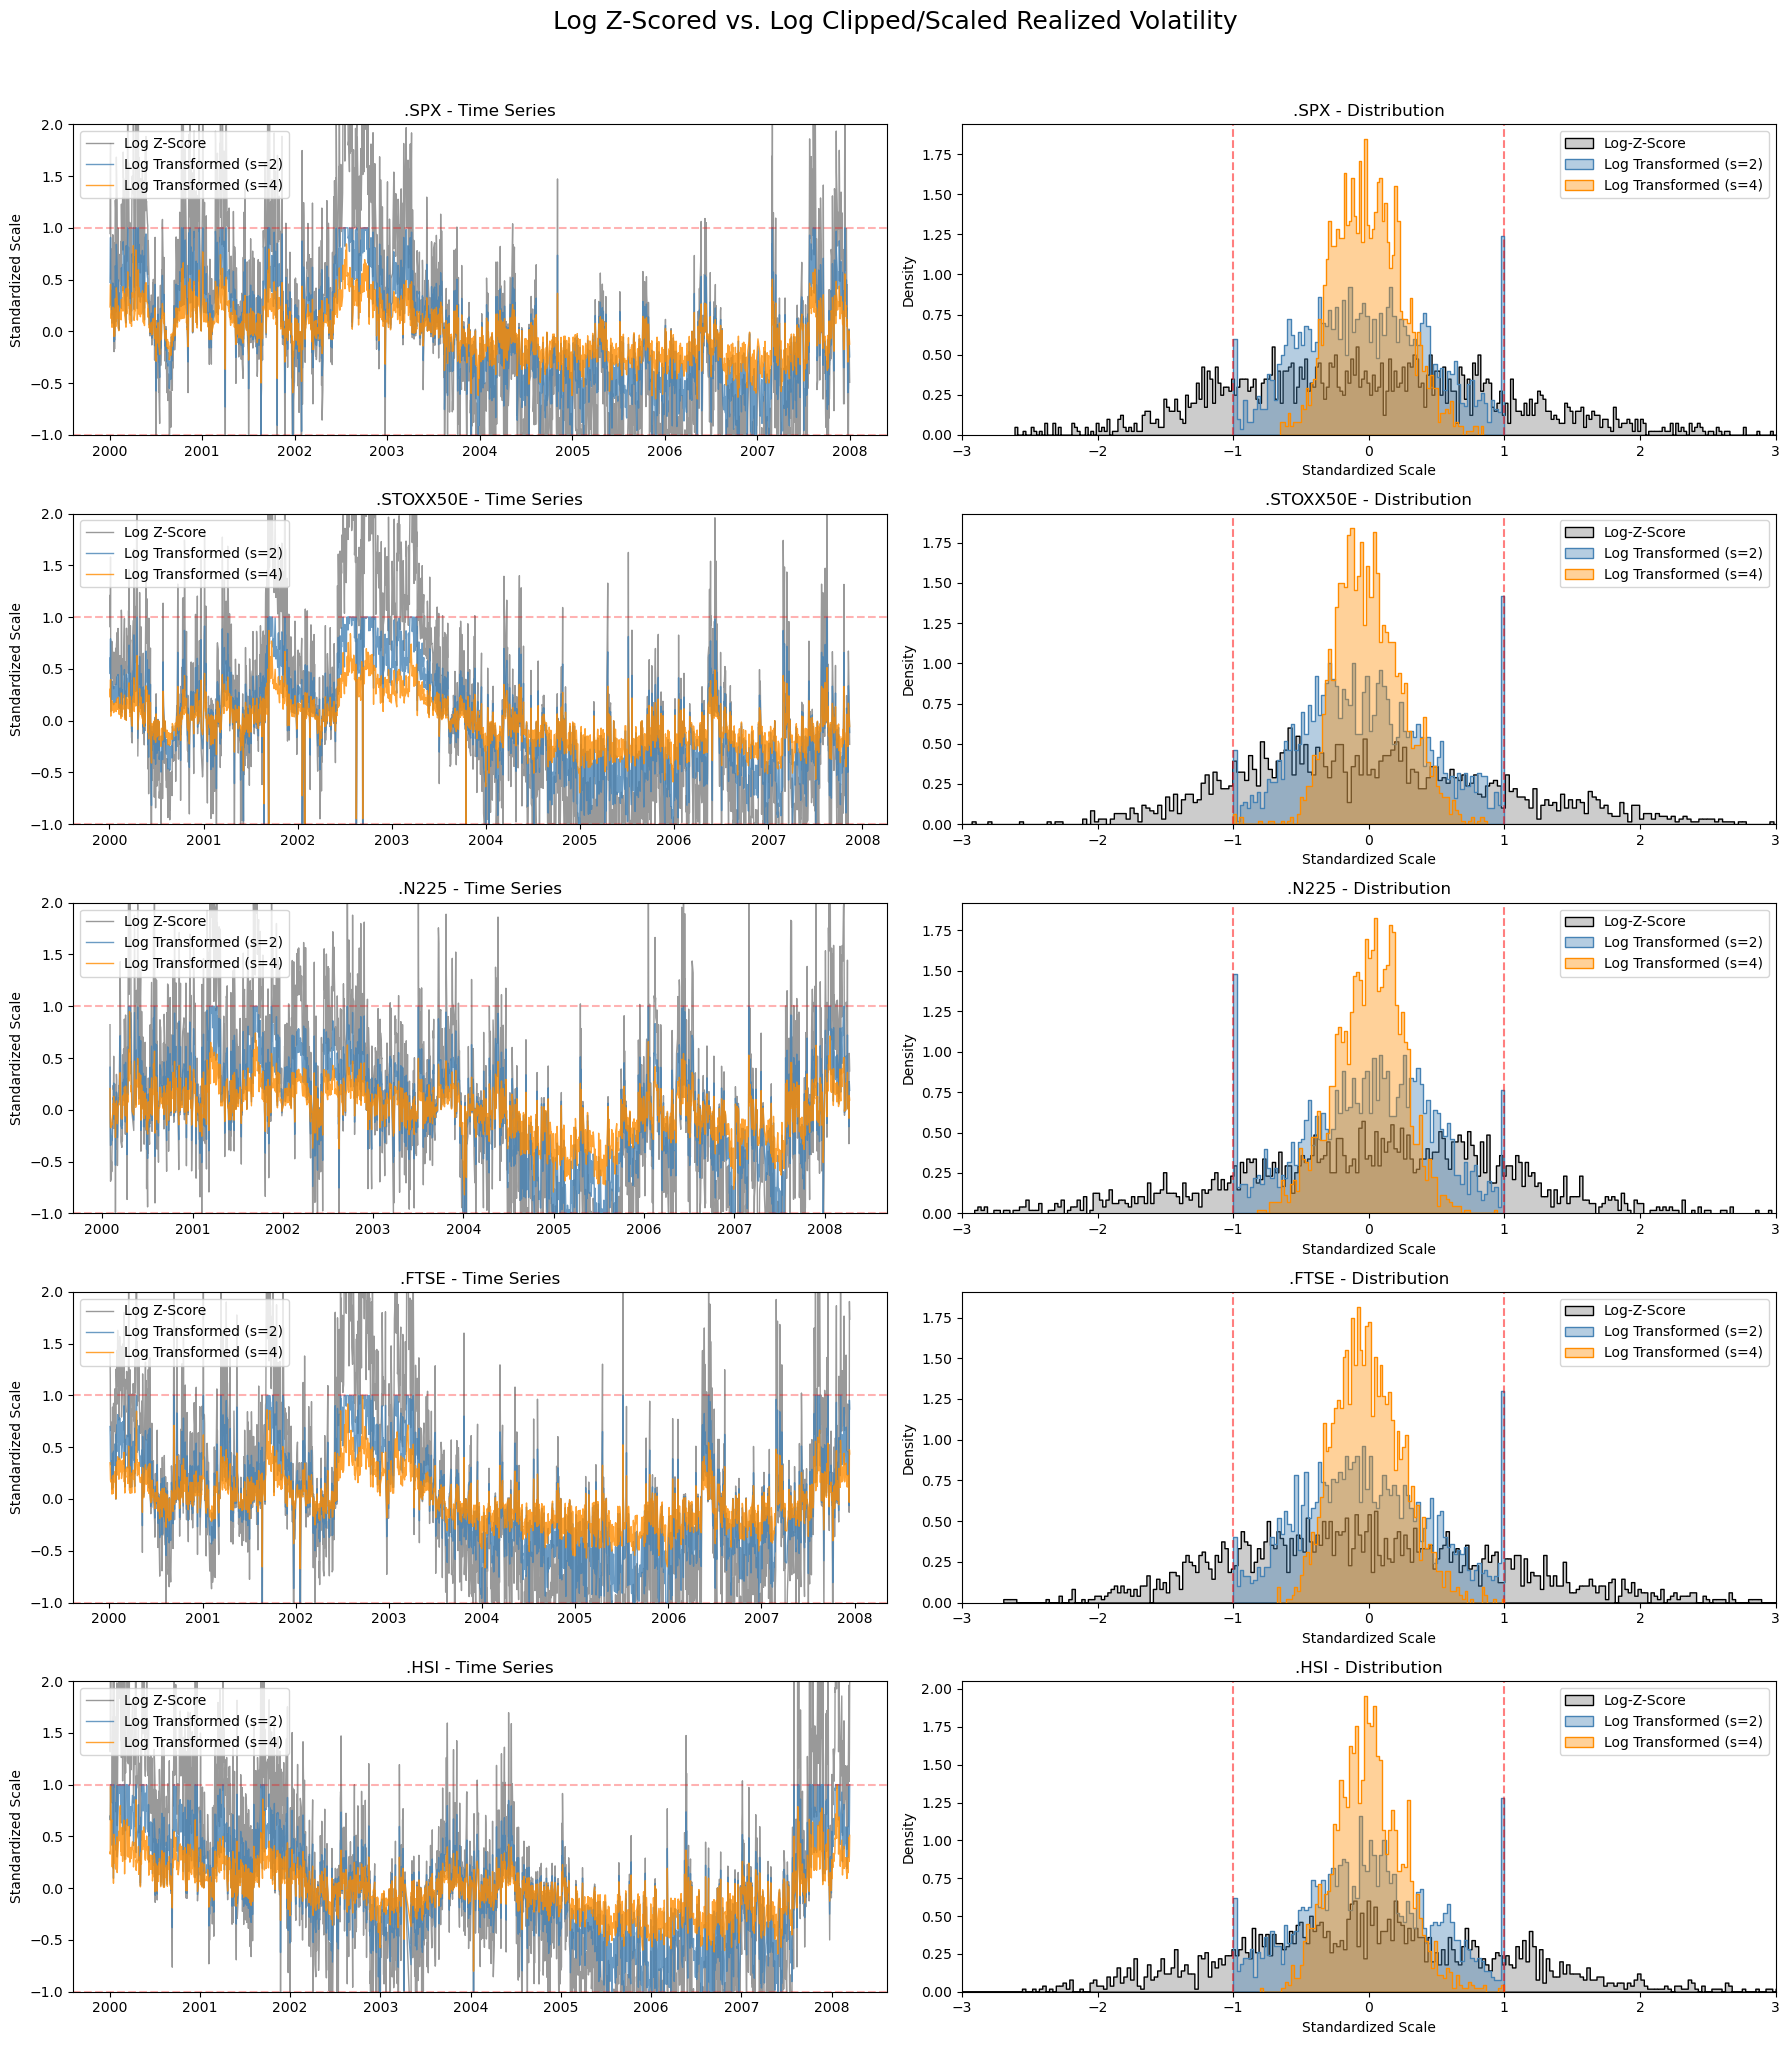

In [21]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Adjust these imports based on your exact project structure
from data.data_loader import load_rv
from utils.transform import TimeSeriesTransformer

start = 0
end = 2000

# 1. Setup Configuration
csv_path = 'rv.csv'
target_col = 'rv5'
selected_tickers = ['.SPX', '.STOXX50E', '.N225', '.FTSE', '.HSI']

# Initialize our transformers
# Default is scalar=1.0 and no clipping, which gives us the pure Z-score
transform_z = TimeSeriesTransformer(scalar=1.0, clip_min=None, clip_max=None)
transform_s2 = TimeSeriesTransformer(scalar=2.0, clip_min=-1.0, clip_max=1.0)
transform_s4 = TimeSeriesTransformer(scalar=4.0, clip_min=-1.0, clip_max=1.0)

# Set up a 5x2 grid for plotting (Rows = Tickers, Col 1 = Time Series, Col 2 = Histograms)
fig, axes = plt.subplots(nrows=len(selected_tickers), ncols=2, figsize=(18, 4 * len(selected_tickers)))
fig.suptitle("Log Z-Scored vs. Log Clipped/Scaled Realized Volatility", fontsize=18, y=1.02)

for i, ticker in enumerate(selected_tickers):
    # Load raw data
    raw_values, dates = load_rv(csv_path, symbol=ticker, target=target_col, log_transform=False)
    raw_values = np.log(raw_values)
    if end is not None:
        raw_values, dates = raw_values[start:end], dates[start:end]
    else:
        raw_values, dates = raw_values[start:], dates[start:]

    # Fit and transform the data
    transform_z.fit(raw_values)
    z_scores = transform_z.transform(raw_values)
    
    transform_s2.fit(raw_values)
    y_s2 = transform_s2.transform(raw_values)
    
    transform_s4.fit(raw_values)
    y_s4 = transform_s4.transform(raw_values)
    
    # ==========================================
    # PLOT 1: Time Series (Left Column)
    # ==========================================
    ax_ts = axes[i, 0]
    
    # Plot everything on the same axis
    ax_ts.plot(dates, z_scores, color='black', alpha=0.4, linewidth=1, label='Log Z-Score')
    ax_ts.plot(dates, y_s2, color='steelblue', alpha=0.8, linewidth=1, label='Log Transformed (s=2)')
    ax_ts.plot(dates, y_s4, color='darkorange', alpha=0.8, linewidth=1, label='Log Transformed (s=4)')
    
    # Formatting
    ax_ts.set_title(f"{ticker} - Time Series")
    ax_ts.set_ylabel("Standardized Scale")
    ax_ts.set_ylim((-1,2))
    
    # Add horizontal lines to highlight the clip bounds
    ax_ts.axhline(1, color='red', linestyle='--', alpha=0.3)
    ax_ts.axhline(-1, color='red', linestyle='--', alpha=0.3)
    ax_ts.legend(loc='upper left')
    
    # ==========================================
    # PLOT 2: Histograms (Right Column)
    # ==========================================
    ax_hist = axes[i, 1]
    
    # Plot densities on a single shared X-axis
    sns.histplot(z_scores, bins=300, color='black', alpha=0.2, stat='density', 
                 label='Log-Z-Score', ax=ax_hist, element="step")
    sns.histplot(y_s2, bins=80, color='steelblue', alpha=0.4, stat='density', 
                 label='Log Transformed (s=2)', ax=ax_hist, element="step")
    sns.histplot(y_s4, bins=80, color='darkorange', alpha=0.4, stat='density', 
                 label='Log Transformed (s=4)', ax=ax_hist, element="step")
    
    # Formatting
    ax_hist.set_title(f"{ticker} - Distribution")
    ax_hist.set_xlabel("Standardized Scale")
    
    # Restrict X-axis slightly so the extreme z-score tails don't compress the view too much,
    # but keep it wide enough to see the difference between the clip and the raw tails.
    ax_hist.set_xlim(-3, 3) 
    
    # Add vertical lines at clip boundaries
    ax_hist.axvline(x=-1, color='red', linestyle='--', alpha=0.5)
    ax_hist.axvline(x=1, color='red', linestyle='--', alpha=0.5)

    ax_hist.legend(loc='upper right')

plt.tight_layout()
plt.show()